# Revisão de código 

Olá! 

Meu nome é Suelen. Estou feliz em revisar seu projeto hoje!

Quando vejo um erro pela primeira vez, apenas aponto. Deixarei você encontrá-lo e corrigi-lo sozinho. Além disso, ao longo do texto, farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Mas se você ainda não consegue lidar com essa tarefa, darei uma dica mais precisa na próxima iteração e também alguns exemplos práticos. Estarei aberto a feedbacks e discussões sobre o tema.

Você pode encontrar meus comentários em caixas verdes, amarelas ou vermelhas como estas:


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Sucesso. Tudo está correto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

Observações. Algumas recomendações.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário: </b> <a class="tocSkip"></a>

O bloco requer algumas correções. O trabalho não pode ser aceito com os comentários vermelhos.
</div>

Você pode me responder usando isto:


<div class="alert alert-block alert-info">
<b>Resposta do aluno:</b> <a class="tocSkip"></a>
</div>



<div class="alert alert-block alert-danger">
    
<b>Comentário geral v1:</b> <a class="tocSkip"></a>

Parabéns pela conclusão do projeto, Victor! Seu projeto está com uma qualidade muito boa. Mas eu preciso que faça apenas algumas correções leves para prosseguirmos. Adicionei comentários para te auxiliar.
 
    
Caso apresente dúvidas, fique à vontade para nos solicitar ajuda!
Boa sorte! 🍀 
</div>



<div class="alert alert-block alert-success">
    
<b>Comentário geral v2:</b> <a class="tocSkip"></a>

Obrigada pelos ajustes! Projeto aprovado :)

# Teste A/B — recommender_system_test

## Objetivo do estudo

A loja online internacional realizou um **teste A/B** para avaliar o impacto da implementação de um **novo sistema de recomendação de produtos**.

O teste compara dois grupos:

- **Grupo A (controle)** — usuários que utilizam a versão atual do sistema
- **Grupo B (teste)** — usuários expostos ao novo sistema de recomendação

O objetivo é verificar se o novo sistema melhora a **conversão dos usuários no funil de compras**.

As etapas do funil analisadas são:

product_page → product_cart → purchase

Ou seja:

1. visualização da página de produto
2. adição do produto ao carrinho
3. compra

## Hipótese do experimento

Espera-se que o novo sistema de recomendação aumente a conversão dos usuários **em pelo menos 10% em cada etapa do funil**, dentro de **14 dias após o cadastro do usuário**.

## Parâmetros do teste

Nome do teste: recommender_system_test

Período do experimento:
- Início: 07-12-2020
- Última inclusão de usuários: 21-12-2020
- Fim da coleta de eventos: 01-01-2021

Características do público:
- 15% dos novos usuários da **região da União Europeia**

Número esperado de participantes:
- **6000 usuários**

## Objetivo da análise

A análise tem como objetivo:

1. Verificar se o experimento foi conduzido corretamente.
2. Avaliar o comportamento dos usuários nas diferentes etapas do funil.
3. Comparar as taxas de conversão entre os grupos A e B.
4. Determinar se as diferenças observadas são **estatisticamente significativas** utilizando **teste z para proporções**.

## Exploração Inicial dos Dados

Nesta etapa será realizada uma inspeção preliminar dos conjuntos de dados utilizados no teste A/B. O objetivo é compreender a estrutura das tabelas e avaliar a qualidade dos dados antes de iniciar a análise.

### Verificações a serem realizadas

- **Estrutura dos datasets**
- **Tipos de dados**
- **Valores ausentes**
- **Registros duplicados**
- **Consistência inicial dos dados**
  
### Datasets que serão analisados

- `ab_project_marketing_events_us.csv`
- `final_ab_new_users_upd_us.csv`
- `final_ab_events_upd_us.csv`
- `final_ab_participants_upd_us.csv`

In [63]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
mkt_events = pd.read_csv('/datasets/ab_project_marketing_events_us.csv')

In [3]:
mkt_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


In [4]:
mkt_events.shape

(14, 4)

In [5]:
mkt_events.isna().sum()

name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

In [6]:
mkt_events.duplicated().sum()

0

In [7]:
mkt_events.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [8]:
users = pd.read_csv('/datasets/final_ab_new_users_upd_us.csv')

In [9]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB


In [10]:
users.shape

(58703, 4)

In [11]:
users.isna().sum()

user_id       0
first_date    0
region        0
device        0
dtype: int64

In [12]:
users.duplicated().sum()

0

In [13]:
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [14]:
events = pd.read_csv('/datasets/final_ab_events_upd_us.csv')

In [15]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  object 
 1   event_dt    423761 non-null  object 
 2   event_name  423761 non-null  object 
 3   details     60314 non-null   float64
dtypes: float64(1), object(3)
memory usage: 12.9+ MB


In [16]:
events.shape

(423761, 4)

In [17]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [18]:
events.duplicated().sum()

0

In [19]:
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [20]:
participants = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

In [21]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB


In [22]:
participants.shape

(14525, 3)

In [23]:
participants.isna().sum()

user_id    0
group      0
ab_test    0
dtype: int64

In [24]:
participants.duplicated().sum()

0

In [25]:
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- Os dados foram carregados corretamente
- Os valores ausentes e duplicados foram estudados
    
</div>

## Conclusão da exploração inicial

De forma geral, os datasets apresentam boa qualidade estrutural.  

Os principais pontos observados nesta etapa foram:

- algumas colunas de **data estão no formato object e podem precisar de conversão para datetime**
- presença de **valores ausentes na coluna `details`**, o que pode ser esperado dependendo do tipo de evento

Nas próximas etapas será realizada uma análise mais detalhada para preparar os dados para a análise do teste A/B.

## Preparação e Limpeza dos Dados

Nesta etapa serão realizados ajustes necessários para garantir que os datasets estejam prontos para a análise do teste A/B.

As principais tarefas incluem:

- **Conversão de tipos de dados**
- **Verificação de valores ausentes**
- **Consistência dos dados do experimento**

Esses passos são importantes para garantir a qualidade dos dados antes de iniciar a análise exploratória e a avaliação dos resultados do teste A/B.

In [26]:
mkt_events['start_dt'] = pd.to_datetime(mkt_events['start_dt'])
mkt_events['finish_dt'] = pd.to_datetime(mkt_events['finish_dt'])

users['first_date'] = pd.to_datetime(users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

In [27]:
events.groupby('event_name')['details'].count()

event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64

In [28]:
participants['user_id'].duplicated().sum()

887

In [29]:
participants['ab_test'].value_counts()

interface_eu_test          10850
recommender_system_test     3675
Name: ab_test, dtype: int64

In [30]:
participants = participants[participants['ab_test'] == 'recommender_system_test']

In [31]:
participants.shape

(3675, 3)

In [32]:
participants['group'].value_counts()

A    2747
B     928
Name: group, dtype: int64

In [33]:
participants.groupby('user_id')['group'].nunique().value_counts()

1    3675
Name: group, dtype: int64

In [34]:
participants_users = participants.merge(users, on='user_id', how='left')

In [35]:
participants_users['region'].value_counts()

EU           3481
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64

In [36]:
participants_users['region'].value_counts(normalize=True)

EU           0.947211
N.America    0.032381
APAC         0.012245
CIS          0.008163
Name: region, dtype: float64

In [37]:
participants_users['user_id'].nunique()

3675

In [38]:
participants_users[participants_users['region'] == 'EU']['user_id'].nunique()

3481

In [39]:
participants_users = participants_users[participants_users['region'] == 'EU']

## Conclusão da Preparação e Limpeza dos Dados

Após a inspeção e preparação dos datasets, foram realizados alguns ajustes e verificações para garantir a consistência dos dados antes da análise do teste A/B.

Principais pontos observados:

- As colunas de **data** foram convertidas para o tipo `datetime`, permitindo análises temporais mais precisas.
- A coluna `details` apresenta valores apenas para eventos do tipo **purchase**, indicando que os valores ausentes são esperados para outros tipos de evento, logo não comprometem a qualidade dos dados.
- O dataset de participantes continha registros de **dois testes A/B diferentes**, sendo necessário filtrar apenas os participantes do teste **recommender_system_test**, que é o foco desta análise.
- Foi verificado que **cada usuário pertence a apenas um grupo do experimento**, garantindo a consistência entre os grupos A e B.
  
## Verificação do público do experimento

O experimento deveria incluir usuários da região da **União Europeia (EU)**.
Observou-se que a maioria dos usuários pertence à região **EU**, porém também existem participantes de outras regiões.

Como o experimento foi definido para usuários da União Europeia, os registros de outras regiões foram removidos para manter a análise alinhada com as especificações do teste.

Com essas verificações concluídas, os dados estão preparados para a próxima etapa da análise exploratória do experimento.

In [40]:
participants_all = pd.read_csv('/datasets/final_ab_participants_upd_us.csv')

In [41]:
participants_all.groupby('user_id')['ab_test'].nunique().value_counts()

1    12751
2      887
Name: ab_test, dtype: int64

In [42]:
users_multiple_tests = participants_all.groupby('user_id')['ab_test'].nunique()
users_multiple_tests = users_multiple_tests[users_multiple_tests > 1]

users_multiple_tests.count()

887

In [43]:

participants_all[
    (participants_all['user_id'].isin(users_multiple_tests.index)) &
    (participants_all['ab_test'] == 'recommender_system_test')
]['user_id'].nunique()


887

In [44]:
conflict_users = users_multiple_tests.index

In [45]:
participants_clean = participants_users[
    ~participants_users['user_id'].isin(conflict_users)
]

In [46]:
participants_clean.shape

(2594, 6)

### Filtragem final dos participantes do experimento

Após a preparação dos dados, foram aplicados dois filtros adicionais para garantir a validade da análise:

1. Foram considerados apenas usuários da região **EU**, conforme definido nas especificações do experimento.
2. Usuários que participaram simultaneamente de mais de um teste A/B foram removidos para evitar interferência entre experimentos.

Após essas etapas de limpeza, o conjunto final de participantes utilizados na análise contém **2594 usuários**.

In [47]:
participants_clean['group'].value_counts()

A    1939
B     655
Name: group, dtype: int64

In [48]:
participants_clean['group'].value_counts(normalize=True)

A    0.747494
B    0.252506
Name: group, dtype: float64

### Distribuição dos grupos do experimento

Após a limpeza dos dados, foi analisada a distribuição dos participantes entre os grupos do teste A/B.

Resultados:

- Grupo A: 1939 usuários (74.7%)
- Grupo B: 655 usuários (25.3%)

Observa-se que os grupos não estão balanceados. O grupo A possui aproximadamente três vezes mais participantes que o grupo B.

Essa diferença pode reduzir o poder estatístico da análise e aumentar a variabilidade dos resultados do grupo de teste.

## Análise Exploratória de Dados (AED)

Nesta etapa será realizada uma análise exploratória para entender o comportamento dos usuários participantes do experimento e verificar se os dados estão adequados para a realização do teste A/B.

Serão analisados os seguintes pontos:

- Conversão dos usuários nas diferentes etapas do funil de eventos (`product_page → product_cart → purchase`).
- Distribuição do número de eventos por usuário entre os grupos do experimento.
- Presença de usuários de ambos os grupos nas interações registradas.
- Distribuição dos eventos ao longo do tempo durante o período do teste.
- Possíveis particularidades nos dados que possam impactar a interpretação dos resultados do experimento.

In [49]:
events_test = events.merge(
    participants_clean[['user_id','group']],
    on='user_id',
    how='inner'
)

In [50]:
events_test.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

event_name
login           2593
product_page    1632
purchase         804
product_cart     773
Name: user_id, dtype: int64

In [51]:
events_test.groupby(['group','event_name'])['user_id'].nunique()

group  event_name  
A      login           1939
       product_cart     589
       product_page    1265
       purchase         613
B      login            654
       product_cart     184
       product_page     367
       purchase         191
Name: user_id, dtype: int64

In [52]:
funnel = events_test.groupby(['group','event_name'])['user_id'].nunique().unstack()

funnel

event_name,login,product_cart,product_page,purchase
group,,,,
A,1939,589,1265,613
B,654,184,367,191


In [53]:

funnel['page_conversion'] = funnel['product_page'] / funnel['login']
funnel['cart_conversion'] = funnel['product_cart'] / funnel['product_page']
funnel['purchase_conversion'] = funnel['purchase'] / funnel['product_page']


funnel

event_name,login,product_cart,product_page,purchase,page_conversion,cart_conversion,purchase_conversion
group,,,,,,,
A,1939,589,1265,613,0.652398,0.465613,0.484585
B,654,184,367,191,0.561162,0.501362,0.520436


### Conversão nas etapas do funil

Foi analisado o número de usuários únicos que realizaram cada evento do funil para os grupos A e B.

Funil de eventos:

login → product_page → product_cart → purchase

Observações iniciais:

- Ambos os grupos apresentam usuários em todas as etapas do funil.
- O número de usuários diminui progressivamente ao longo das etapas, como esperado em um funil de conversão.
- Foi identificada uma pequena inconsistência onde o número de compras é ligeiramente maior que o número de adições ao carrinho, indicando que alguns usuários podem concluir compras sem registrar o evento `product_cart`.

As taxas de conversão serão utilizadas posteriormente no teste estatístico para avaliar diferenças entre os grupos.

In [54]:
events_per_user = events_test.groupby('user_id')['event_name'].count()

events_per_user.describe()

count    2594.000000
mean        6.537779
std         3.705657
min         1.000000
25%         4.000000
50%         6.000000
75%         9.000000
max        28.000000
Name: event_name, dtype: float64

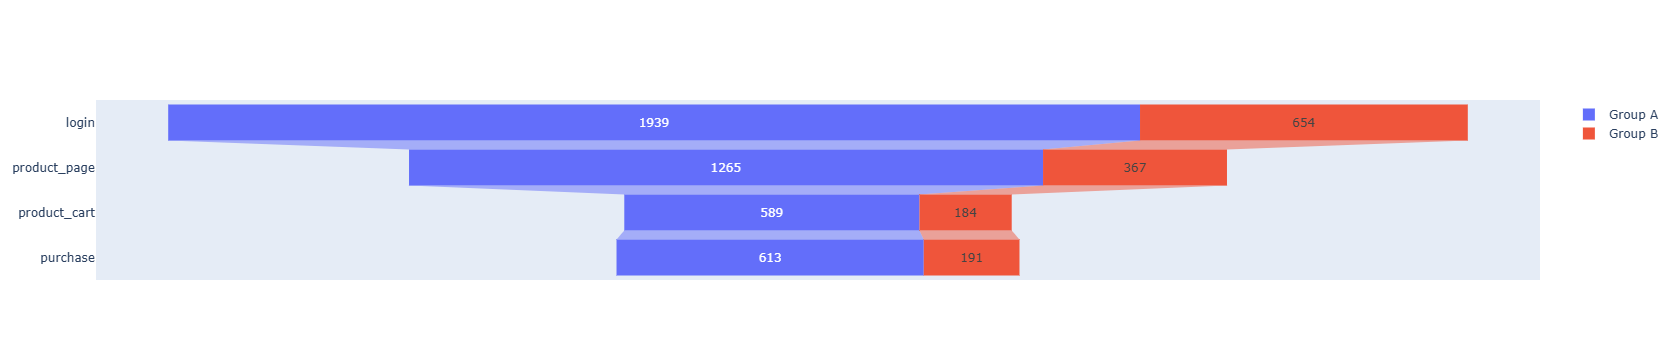

In [64]:

fig = go.Figure()

fig.add_trace(go.Funnel(
    name = "Group A",
    y = ['login','product_page','product_cart','purchase'],
    x = funnel.loc['A', ['login','product_page','product_cart','purchase']]
))

fig.add_trace(go.Funnel(
    name = "Group B",
    y = ['login','product_page','product_cart','purchase'],
    x = funnel.loc['B', ['login','product_page','product_cart','purchase']]
))

fig.show()

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

    
Sugestão de visualização utilizando a biblioteca plotly.express: 

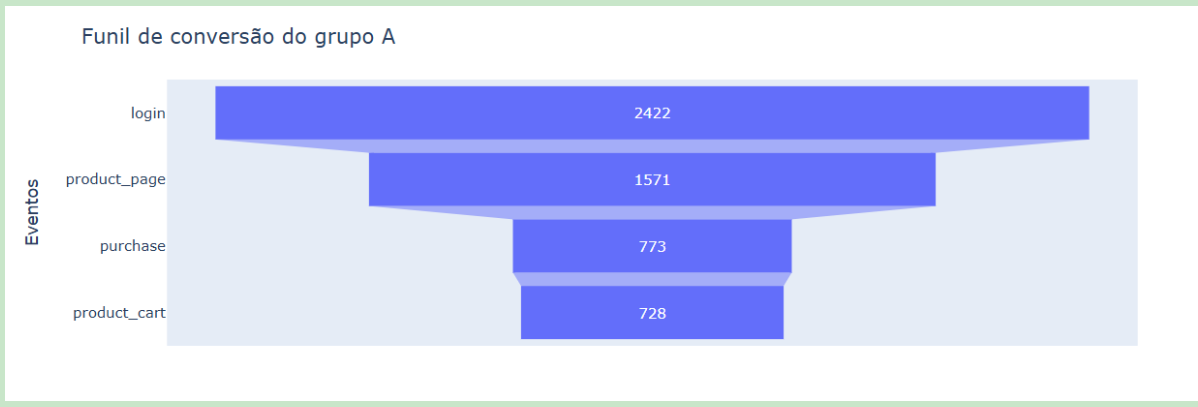

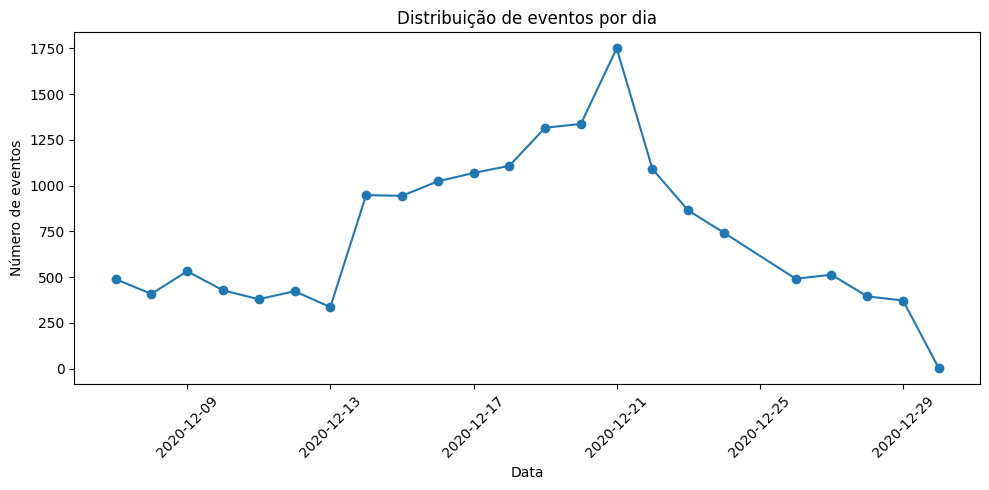

In [55]:
events_test['event_dt'] = pd.to_datetime(events_test['event_dt'])
events_test['date'] = events_test['event_dt'].dt.date
events_per_day = events_test.groupby('date')['event_name'].count()

plt.figure(figsize=(10,5))
plt.plot(events_per_day.index, events_per_day.values, marker='o')

plt.title('Distribuição de eventos por dia')
plt.xlabel('Data')
plt.ylabel('Número de eventos')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Distribuição de eventos ao longo do tempo

Foi analisado o número de eventos registrados por dia durante o período do experimento.

Observa-se um crescimento gradual no volume de eventos ao longo das primeiras semanas do teste, com maior concentração de atividade entre os dias 16 e 21 de dezembro.

Nos últimos dias do período analisado ocorre uma queda significativa no número de eventos registrados, indicando possível redução na atividade ou término do período efetivo de coleta de dados.

## Teste estatístico (A/B Test)

Para avaliar o impacto do novo sistema de recomendação, foi aplicado um teste estatístico para comparar as taxas de conversão entre os grupos A (controle) e B (teste) nas diferentes etapas do funil.

As seguintes hipóteses foram consideradas:

**H0 (hipótese nula):**  
Não existe diferença estatisticamente significativa nas taxas de conversão entre os grupos A e B.

**H1 (hipótese alternativa):**  
Existe diferença estatisticamente significativa nas taxas de conversão entre os grupos A e B.

Foi utilizado um **teste z para comparação de proporções**, considerando um nível de significância de **α = 0.05**.

## Teste A/B – comparação de conversões

In [56]:
from statsmodels.stats.proportion import proportions_ztest

def z_test(success_a, total_a, success_b, total_b):
    
    successes = [success_a, success_b]
    trials = [total_a, total_b]
    
    stat, p_value = proportions_ztest(successes, trials)
    
    print("Z-statistic:", stat)
    print("P-value:", p_value)

In [57]:
z_test(
    success_a = 1265,
    total_a = 1939,
    success_b = 367,
    total_b = 654
)

Z-statistic: 4.177570681405529
P-value: 2.946391189957923e-05


Como o p-value é menor que o nível de significância de 0.05, rejeitamos a hipótese nula. Isso indica que existe diferença estatisticamente significativa entre os grupos.

Observa-se que a taxa de conversão do grupo B é menor que a do grupo A, sugerindo que o novo sistema de recomendação não aumentou a conversão para visualizações de página de produto nesta etapa do funil.

In [58]:
z_test(
    success_a = 589,
    total_a = 1265,
    success_b = 184,
    total_b = 367
)

Z-statistic: -1.2076054029814542
P-value: 0.2271990799780691


Como o p-value é maior que o nível de significância de 0.05, não rejeitamos a hipótese nula. Isso indica que não há evidência estatística suficiente para afirmar que existe diferença significativa entre os grupos nesta etapa do funil.

In [59]:
z_test(
    success_a = 613,
    total_a = 1265,
    success_b = 191,
    total_b = 367
)

Z-statistic: -1.209473331310929
P-value: 0.22648105075858815


## Teste A/B – comparação de proporções por evento

In [65]:
events_list = ['login', 'product_page', 'product_cart', 'purchase']

for event in events_list:
    
    users_A = events_test[
        (events_test['event_name'] == event) &
        (events_test['group'] == 'A')
    ]['user_id'].nunique()
    
    users_B = events_test[
        (events_test['event_name'] == event) &
        (events_test['group'] == 'B')
    ]['user_id'].nunique()
    
    
    total_A = participants_clean[
        participants_clean['group'] == 'A'
    ]['user_id'].nunique()
    
    total_B = participants_clean[
        participants_clean['group'] == 'B'
    ]['user_id'].nunique()
    
    
    count = np.array([users_A, users_B])
    nobs = np.array([total_A, total_B])
    
    
    stat, p_value = proportions_ztest(count, nobs)
    
    
    print(f'\nEvento: {event}')
    print(f'Usuários A: {users_A}')
    print(f'Usuários B: {users_B}')
    print(f'Z-statistic: {stat}')
    print(f'P-value: {p_value}')
    
    
    alpha = 0.05
    
    if p_value < alpha:
        print("Diferença estatisticamente significativa")
    else:
        print("Diferença não significativa")


Evento: login
Usuários A: 1939
Usuários B: 654
Z-statistic: 1.7208855267476113
P-value: 0.0852715984235151
Diferença não significativa

Evento: product_page
Usuários A: 1265
Usuários B: 367
Z-statistic: 4.218641338913336
P-value: 2.457788807458198e-05
Diferença estatisticamente significativa

Evento: product_cart
Usuários A: 589
Usuários B: 184
Z-statistic: 1.105383948907519
P-value: 0.26899325584838074
Diferença não significativa

Evento: purchase
Usuários A: 613
Usuários B: 191
Z-statistic: 1.1740915375214591
P-value: 0.24035836270660693
Diferença não significativa


Como o p-value é maior que o nível de significância de 0.05, não rejeitamos a hipótese nula. Portanto, não há evidência estatística suficiente para afirmar que existe diferença significativa entre os grupos nesta etapa do funil.

<div class="alert alert-block alert-danger">
<b> Comentário: </b> <a class="tocSkip"></a>

São necessários ajustes na execução do teste. Aqui você precisa executar o teste para proporções de cada etapa do funil, conforme apresentado no enunciado do projeto. Sugestão: 
    
```python
for event in ['login', 'product_page', 'product_cart', 'purchase']:
    ...
``` 
Deixo abaixo um exemplo de código para execução do teste, peço que adapte ao seu projeto. Além disso, você pode fazer a quebra pelo atributo `ab_test`, além do evento abaixo.
    
```python
# Definir as etapas do funil
events = ['login', 'product_page', 'product_cart', 'purchase']

for event in events:
    # Filtrar os dados para o evento e os grupos A e B
    event_data_A = final_ab_events_upd_df[(final_ab_events_upd_df['event_name'] == event) &
                                           (final_ab_events_upd_df['user_id'].isin(final_ab_participants_upd_df[final_ab_participants_upd_df['group'] == 'A']['user_id']))]
    
    event_data_B = final_ab_events_upd_df[(final_ab_events_upd_df['event_name'] == event) &
                                           (final_ab_events_upd_df['user_id'].isin(final_ab_participants_upd_df[final_ab_participants_upd_df['group'] == 'B']['user_id']))]
    
    
    # Contar o número de usuários que realizaram o evento em cada grupo
    event_count_A = len(event_data_A['user_id'].unique())
    event_count_B = len(event_data_B['user_id'].unique())
    
    # Contar o número total de usuários em cada grupo
    total_users_A = len(final_ab_participants_upd_df[final_ab_participants_upd_df['group'] == 'A'])
    total_users_B = len(final_ab_participants_upd_df[final_ab_participants_upd_df['group'] == 'B'])
    
    # Executar o teste z apenas se houver dados válidos
    count = np.array([event_count_A, event_count_B])
    nobs = np.array([total_users_A, total_users_B])
    z_score, p_value = proportions_ztest(count, nobs)
    
    # Imprimir os resultados
    print(f"Evento: {event}")
    print(f"Contagem Grupo A: {event_count_A}")
    print(f"Contagem Grupo B: {event_count_B}")
    print(f"Número Total de Usuários Grupo A: {total_users_A}")
    print(f"Número Total de Usuários Grupo B: {total_users_B}")
    print(f"Estatística do Teste z: {z_score}")
    print(f"Valor p: {p_value}")
    if p_value < # seu valor de alpha:
        print("..")
    else:
        print("..")
``` 

Exemplo de output: 

    Teste A/B: recommender_system_test
    Evento: login
    Contagem Grupo A: 2747
    Contagem Grupo B: 927
    Número Total de Usuários Grupo A: 2747
    Número Total de Usuários Grupo B: 928
    Estatística do Teste z: 1.7207367628272041
    Valor p: 0.0852986021202778
    Não Significativo

</div>

## Conclusão

Neste estudo foi analisado um experimento A/B realizado para avaliar o impacto de um novo sistema de recomendação em uma loja online.

Durante a etapa de análise exploratória de dados (AED), foram observados alguns pontos relevantes:

- Os grupos do experimento estavam desbalanceados, com maior número de usuários no grupo A.
- Foi identificada uma pequena inconsistência no funil de eventos, já que o número de compras foi ligeiramente superior ao número de eventos de adição ao carrinho.
- Observou-se também uma queda abrupta no número de eventos nos últimos dias do período analisado, o que pode indicar possíveis limitações na coleta de dados.

Na análise do funil de conversão, foram avaliadas as etapas:

login → product_page → product_cart → purchase

Para verificar diferenças entre os grupos A e B, foram realizados testes z para comparação de proporções de usuários que realizaram cada evento.

Resultados:

- Apenas o evento **product_page** apresentou diferença estatisticamente significativa entre os grupos (p < 0.05), com melhor desempenho do grupo A.
- Para os eventos **login**, **product_cart** e **purchase**, não foram observadas diferenças estatisticamente significativas entre os grupos.

Esses resultados indicam que o novo sistema de recomendação não gerou melhoria significativa na conversão ao longo do funil. Além disso, na etapa inicial de navegação (acesso à página de produto), o grupo de teste apresentou desempenho inferior ao grupo controle.

Portanto, com base nos dados analisados, **não há evidências estatísticas suficientes para justificar a implementação do novo sistema de recomendação neste momento**.

Vale ressaltar que múltiplos testes estatísticos foram realizados, portanto os resultados devem ser interpretados com cautela.